In [1]:
!pip install stumpy

In [2]:
import pandas as pd
import stumpy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


In [3]:
df=pd.read_csv("EUR_USD_2020_M5.csv")

In [4]:
dfs=df.iloc[:1000]

In [5]:
dfs['time']=pd.to_datetime(dfs['time'])


C:\Users\sliso\AppData\Local\Temp\ipykernel_7000\777572360.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['time']=pd.to_datetime(dfs['time'])


In [7]:
dfs.set_index('time', inplace=True)

In [9]:
dfs

,o,h,l,c,volume,complete
time,,,,,,
2020-01-01 22:00:00+00:00,1.12124,1.12146,1.12124,1.12132,9,True
2020-01-01 22:05:00+00:00,1.12137,1.12137,1.12125,1.12125,5,True
2020-01-01 22:10:00+00:00,1.12129,1.12129,1.12125,1.12125,2,True
2020-01-01 22:15:00+00:00,1.12135,1.12155,1.12134,1.12146,12,True
2020-01-01 22:20:00+00:00,1.12143,1.12154,1.12143,1.12154,4,True
...,...,...,...,...,...,...
2020-01-07 09:35:00+00:00,1.11829,1.11843,1.11812,1.11836,91,True
2020-01-07 09:40:00+00:00,1.11834,1.11846,1.11824,1.11829,51,True
2020-01-07 09:45:00+00:00,1.11827,1.11828,1.11806,1.11826,64,True


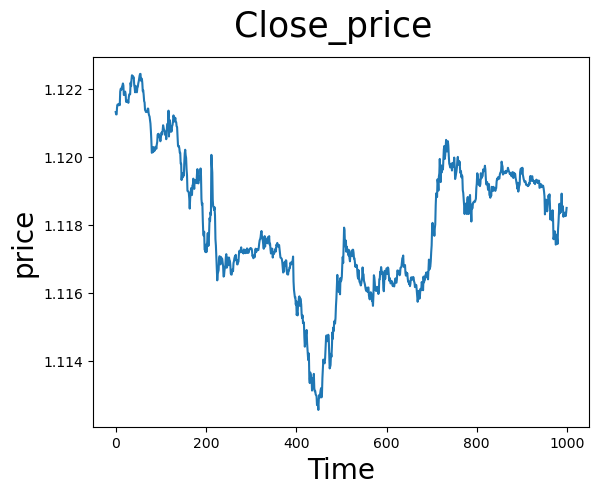

In [8]:
plt.suptitle('Close_price', fontsize='25')
plt.xlabel('Time', fontsize ='20')
plt.ylabel('price', fontsize='20')
plt.plot(dfs['c'].values)
plt.show()

In [10]:
m = 60
mp = stumpy.stump(dfs['c'], m)
true_P = mp[:, 0]

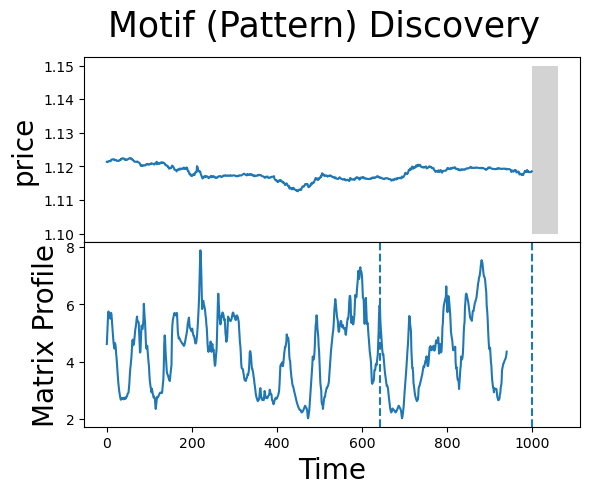

In [18]:
fig, axs = plt.subplots(2, sharex=True, gridspec_kw={'hspace': 0})
plt.suptitle('Motif (Pattern) Discovery', fontsize='25')

axs[0].plot(dfs['c'].values)
axs[0].set_ylabel('price', fontsize='20')
rect = Rectangle((1000, 1.1), m,0.05, facecolor='lightgrey')
axs[0].add_patch(rect)
rect = Rectangle((1000, 1.1), m, 0.05, facecolor='lightgrey')
axs[0].add_patch(rect)
axs[1].set_xlabel('Time', fontsize ='20')
axs[1].set_ylabel('Matrix Profile', fontsize='20')
axs[1].axvline(x=643, linestyle="dashed")
axs[1].axvline(x=1000, linestyle="dashed")
axs[1].plot(true_P)
plt.show()